In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")

In [3]:
# Display the first 5 rows
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [4]:
# Display dataset information
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null

In [5]:
# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [6]:
# Display shape of dataset
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(7043, 21)


In [7]:
# Display column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [8]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [10]:
# ==========================================
# Part 2: Data Cleaning
# ==========================================

# Drop customerID column (not useful for prediction)
df.drop("customerID", axis=1, inplace=True)

# Replace blank spaces in TotalCharges with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Check missing values
print("\nMissing Values After Conversion:")
print(df.isnull().sum())

# Remove rows with missing values
df.dropna(inplace=True)

# Verify dataset shape
print("\nDataset Shape After Cleaning:")
print(df.shape)

# Check data types
print("\nUpdated Data Types:")
print(df.dtypes)


Missing Values After Conversion:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Dataset Shape After Cleaning:
(7032, 20)

Updated Data Types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessB


Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


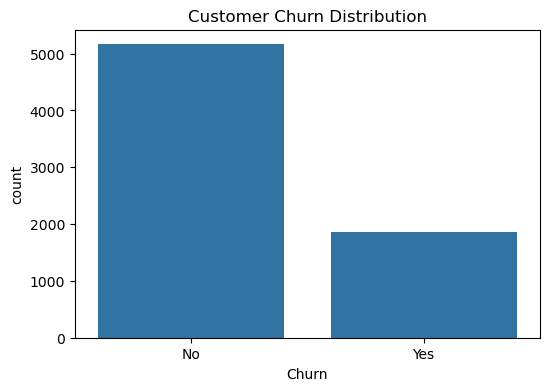

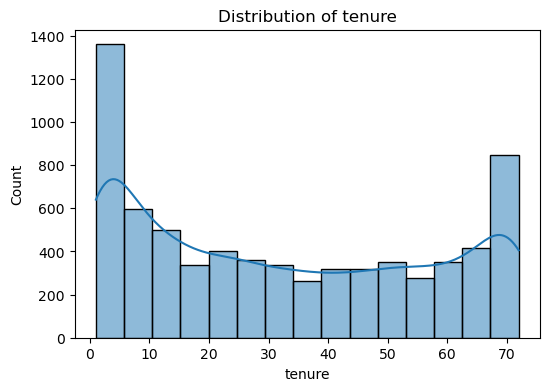

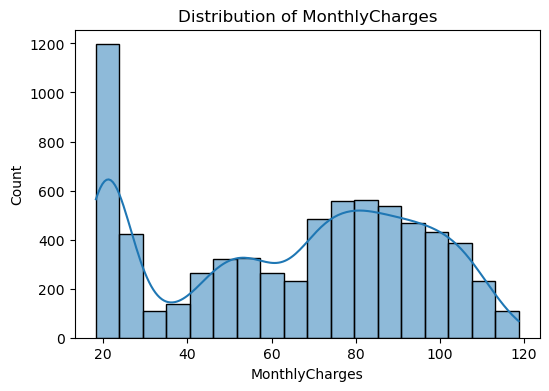

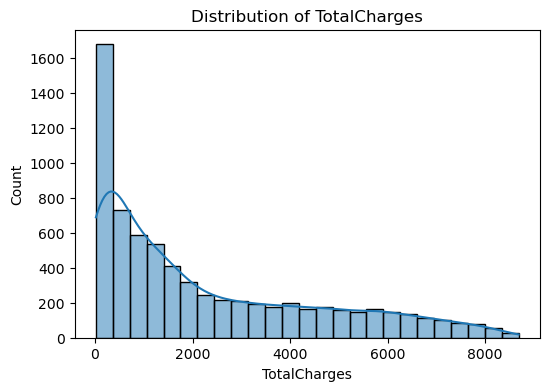

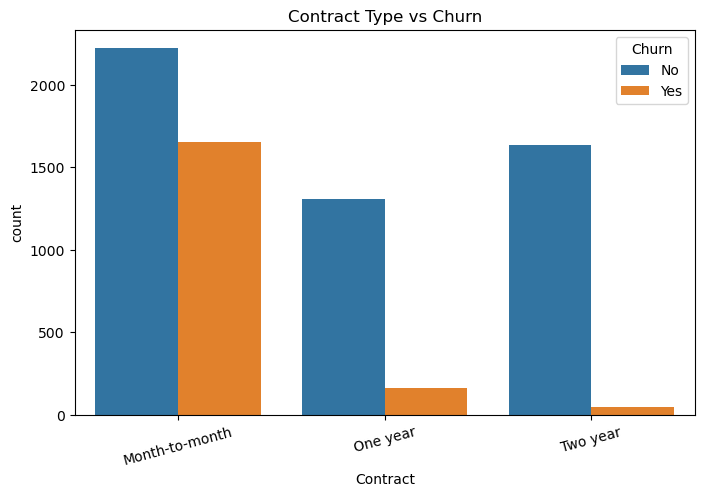

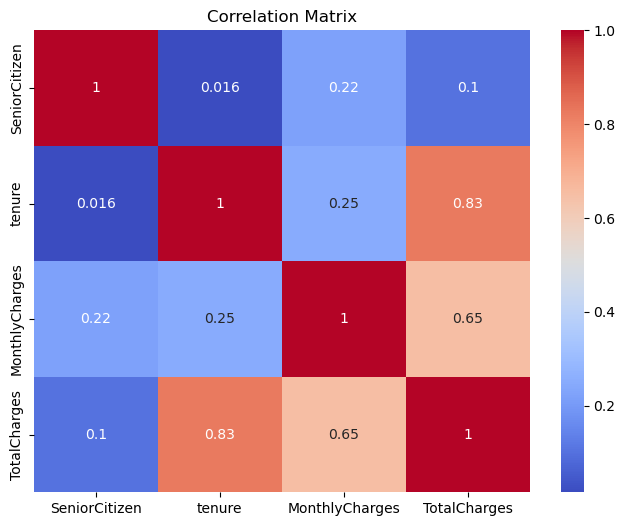

In [11]:

# ==========================================
# Part 3: Exploratory Data Analysis (EDA)
# ==========================================

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()


plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use("ggplot")
sns.set_palette("Set2")

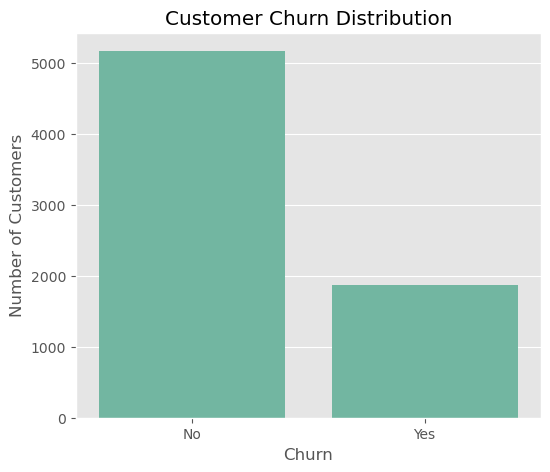

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print(df["Churn"].value_counts())

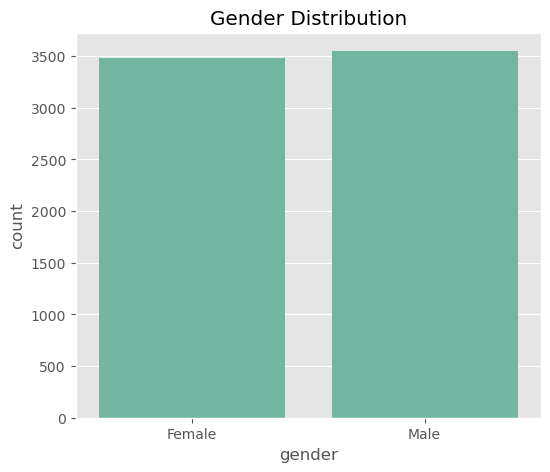

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")

plt.show()

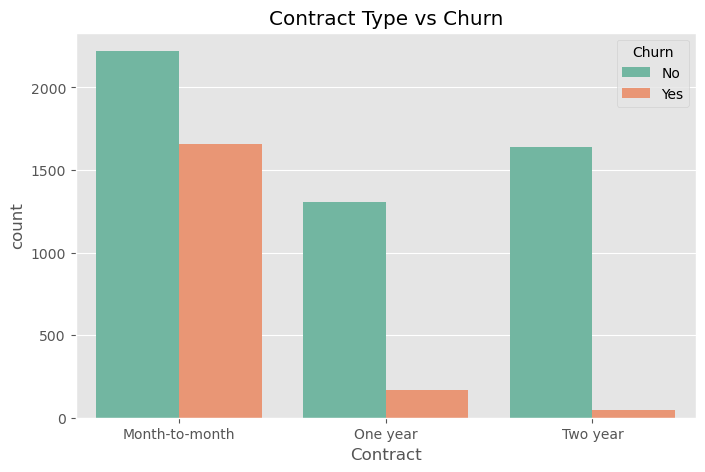

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

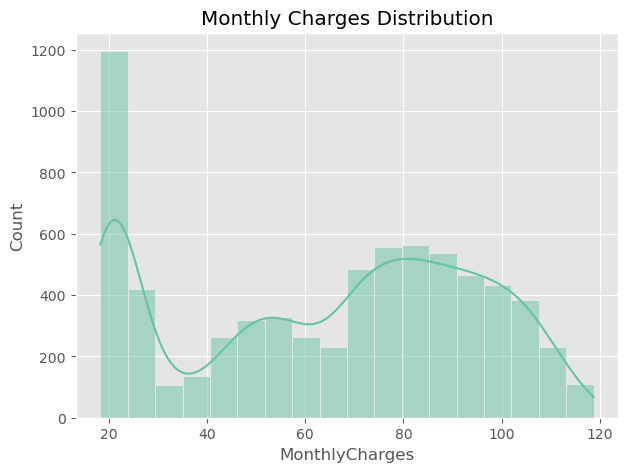

In [16]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["MonthlyCharges"],
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

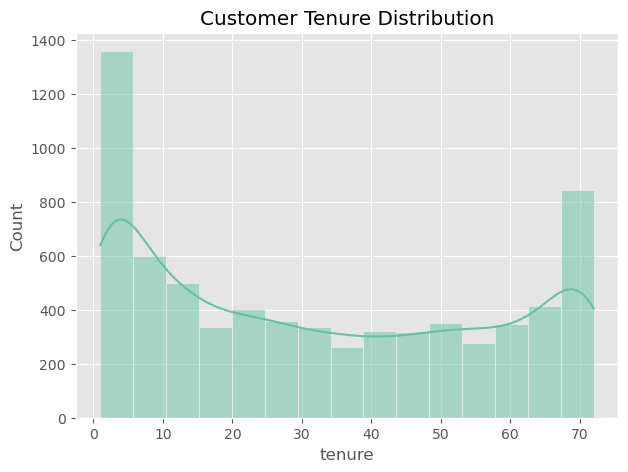

In [17]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["tenure"],
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

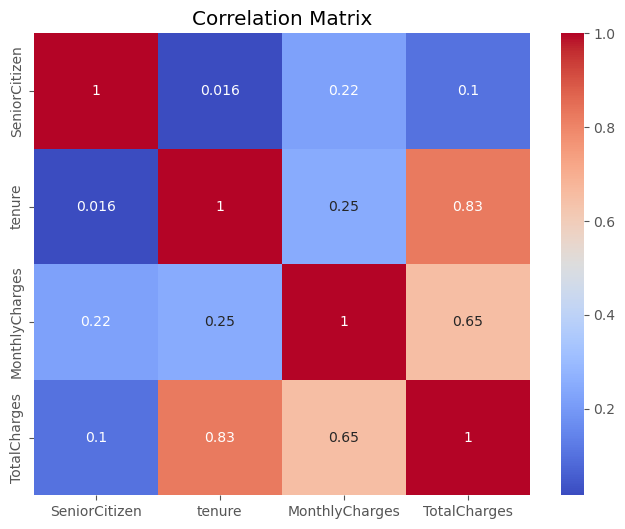

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

In [20]:
# Create a dictionary to store encoders
label_encoders = {}

# Select all categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Apply Label Encoding
for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

print("Categorical columns encoded successfully!")

C:\Users\sejal\AppData\Local\Temp\ipykernel_242512\1310512179.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Categorical columns encoded successfully!


In [21]:
# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7032, 19)
Target Shape: (7032,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5625, 19)
Testing Data: (1407, 19)


In [23]:
# Numerical columns
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

# Transform testing data
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [24]:
joblib.dump(label_encoders, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Encoders and scaler saved successfully!")

Encoders and scaler saved successfully!


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [26]:
# Create models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate
results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("=" * 50)
    print(name)
    print("Accuracy:", round(accuracy * 100, 2), "%")

Logistic Regression
Accuracy: 79.32 %
Decision Tree
Accuracy: 71.43 %
Random Forest
Accuracy: 78.11 %


In [27]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,0.793177
2,Random Forest,0.781095
1,Decision Tree,0.714286


In [28]:
# Final model
final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [29]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
0.7810945273631841

Confusion Matrix:
[[920 113]
 [195 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



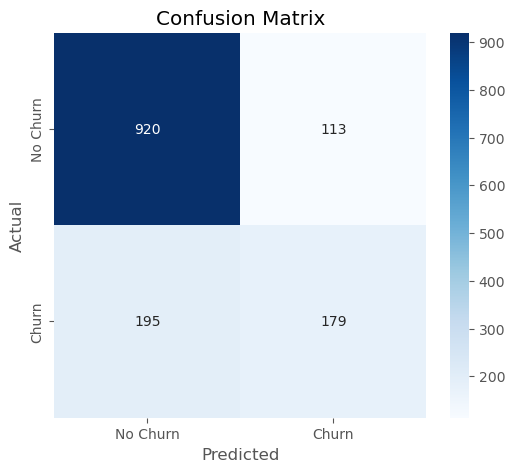

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
import joblib

In [32]:
# Save trained model
joblib.dump(final_model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
# Save label encoders
joblib.dump(label_encoders, "encoder.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Encoders and Scaler saved successfully!")

Encoders and Scaler saved successfully!


In [34]:
import os

print("Generated Files:\n")

files = [
    "model.pkl",
    "encoder.pkl",
    "scaler.pkl"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {file}")
    else:
        print(f"❌ {file} not found")

Generated Files:

✅ model.pkl
✅ encoder.pkl
✅ scaler.pkl
